In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
import timm
from torch.utils.data import DataLoader, SubsetRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
import itertools

# Constants
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 8
EPOCHS = 50
PATIENCE = 5
WEIGHT_DECAY = 1e-3  # Increased weight decay for more regularization
LABEL_SMOOTHING = 0.1
MIXUP_ALPHA = 0.2

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Enhanced data augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.5)  # Added random erasing to prevent overfitting
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Mixup function
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# Load dataset
DATASET_PATH = '/kaggle/input/dataset/Augmented Dataset'
dataset = torchvision.datasets.ImageFolder(DATASET_PATH, transform=data_transforms['train'])
class_names = dataset.classes
print(f"Classes found: {class_names}")

# Dataset splitting
def dataset_split(dataset, train_split=0.75, val_split=0.15, test_split=0.15):
    dataset_size = len(dataset)
    indices = list(range(dataset_size))
    np.random.seed(12)
    np.random.shuffle(indices)
    
    train_size = int(train_split * dataset_size)
    val_size = int(val_split * dataset_size)
    
    train_indices = indices[:train_size]
    val_indices = indices[train_size:train_size + val_size]
    test_indices = indices[train_size + val_size:]
    
    train_sampler = SubsetRandomSampler(train_indices)
    val_sampler = SubsetRandomSampler(val_indices)
    test_sampler = SubsetRandomSampler(test_indices)
    
    train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0, pin_memory=True)
    val_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=val_sampler, num_workers=0, pin_memory=True)
    test_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=test_sampler, num_workers=0, pin_memory=True)
    
    print(f"Train size: {len(train_indices)}, Val size: {len(val_indices)}, Test size: {len(test_indices)}")
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = dataset_split(dataset)

# Model: MobileNetV3 Small
def get_mobilenetv3_small(num_classes, device):
    model = timm.create_model('mobilenetv3_small_100', pretrained=True, num_classes=num_classes)
    return model.to(device)

# Define the model
class EnsembleModel(nn.Module):
    def __init__(self, mobilenet_model, num_classes, feature_dim=512):
        super(EnsembleModel, self).__init__()
        self.mobilenet = mobilenet_model
        self.dropout = nn.Dropout(0.7)  # Increased dropout rate to prevent overfitting
        self.fc = nn.Linear(1280, num_classes)  # MobileNetV3 Small output channels are 1280

    def forward(self, x):
        # Pass input through MobileNetV3
        features = self.mobilenet(x)
        
        # Apply global average pooling if features have more than 2 dimensions (H, W)
        if features.dim() > 2:  # Check if the output is a 4D tensor (batch_size, channels, H, W)
            features = features.mean([2, 3])  # Global average pooling to reduce H, W to a single value per channel
        
        # Apply dropout
        features = self.dropout(features)
        
        # Pass the output to the fully connected layer
        output = self.fc(features)
        return output

# Initialize MobileNetV3 Small model
mobilenet_model = get_mobilenetv3_small(NUM_CLASSES, device)
model = EnsembleModel(mobilenet_model, NUM_CLASSES).to(device)

# Freeze base layers (optional fine-tuning)
for param in mobilenet_model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

# Loss and optimizer setup
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Training loop with Mixup
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience=PATIENCE):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', unit='batch')
        for batch_idx, (images, labels) in enumerate(train_pbar):
            images, labels = images.to(device), labels.to(device)

            # Apply Mixup
            images, labels_a, labels_b, lam = mixup_data(images, labels, MIXUP_ALPHA)

            optimizer.zero_grad()
            outputs = model(images)

            # Supervised loss with Mixup
            loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels_a).sum().item()  # Accuracy based on primary labels

            train_pbar.set_postfix({
                'loss': running_loss / total,
                'accuracy': correct / total,
            })

        # Log training metrics
        train_loss = running_loss / total
        train_acc = correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        # Validation step
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_loss / total
        val_acc = correct / total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        scheduler.step(val_loss)

        print(f"Epoch {epoch + 1}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}, val_loss={val_loss:.4f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch + 1}")
                model.load_state_dict(best_model_state)
                break

    return history

# Train the model
history = train_model(model, train_loader, val_loader, criterion, optimizer, EPOCHS)

# Plot training history
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Evaluation
def evaluate_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    y_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
    roc_auc = roc_auc_score(y_true_bin, y_probs, average='weighted', multi_class='ovr')

    print(f"✅ Overall Accuracy: {accuracy:.4f}")
    print(f"✅ Precision: {precision:.4f}")
    print(f"✅ Recall: {recall:.4f}")
    print(f"✅ F1-Score: {f1:.4f}")
    print(f"✅ ROC AUC Score: {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plot_confusion_matrix(cm, class_names)

# Confusion matrix
def plot_confusion_matrix(cm, classes, normalize=False):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# Run evaluation on the test set
evaluate_model(model, test_loader)


Using device: cuda
Classes found: ['Antracnose', 'Bacterial Spot', 'Healthy Leaf', 'Leaf Curl', 'Mealybug', 'Mite Disease', 'Mosaic', 'Ring Spot']
Train size: 7006, Val size: 1401, Test size: 935


Epoch 1/50:   0%|          | 0/438 [00:00<?, ?batch/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (16x8 and 1280x8)

Files removed: 12
Name: pytorch-gradcam
Version: 0.2.1
Summary: A Simple pytorch implementation of GradCAM, and GradCAM++
Home-page: https://github.com/vickyliin/gradcam_plus_plus-pytorch
Author: vickyliin
Author-email: vickyliinn@gmail.com
License: 
Location: /usr/local/lib/python3.11/dist-packages
Requires: numpy, opencv-python
Required-by: 
pytorch_grad_cam modules imported successfully
Using device: cuda
Classes found: ['Antracnose', 'Bacterial Spot', 'Healthy Leaf', 'Leaf Curl', 'Mealybug', 'Mite Disease', 'Mosaic', 'Ring Spot']
Dataset size: 9342
Train size: 6539, Val size: 1401, Test size: 1402


Extracting features: 100%|██████████| 409/409 [02:06<00:00,  3.24it/s]


Extracted features shape: (6539, 7)
Scaled features shape: (6539, 7)
Reduced features shape: (6539, 7)


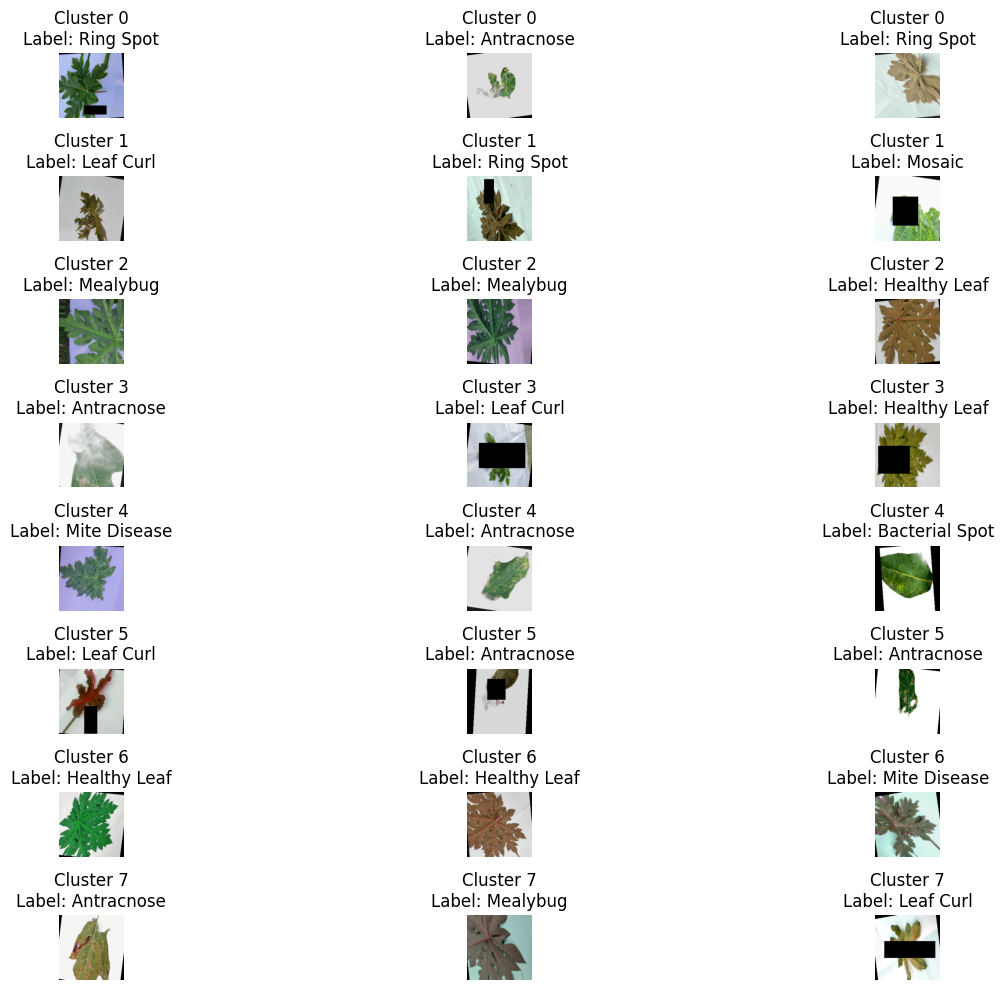

Epoch 1/50: 100%|██████████| 409/409 [02:14<00:00,  3.05batch/s, loss=2.55, accuracy=0.268, pseudo_acc=0.134]


409/409 ━━━━━━━━━━━━━━━━━━━━ 160s 0s/step - accuracy: 0.2679 - loss: 2.5469 - val_accuracy: 0.6916 - val_loss: 1.5511


Epoch 2/50: 100%|██████████| 409/409 [02:13<00:00,  3.06batch/s, loss=2.2, accuracy=0.412, pseudo_acc=0.13]  


409/409 ━━━━━━━━━━━━━━━━━━━━ 160s 0s/step - accuracy: 0.4121 - loss: 2.2005 - val_accuracy: 0.7802 - val_loss: 1.1940


Epoch 3/50: 100%|██████████| 409/409 [02:14<00:00,  3.04batch/s, loss=2.05, accuracy=0.471, pseudo_acc=0.126]


...

409/409 ━━━━━━━━━━━━━━━━━━━━ 159s 0s/step - accuracy: 0.5810 - loss: 1.7428 - val_accuracy: 0.9757 - val_loss: 0.6796


Epoch 25/50: 100%|██████████| 409/409 [02:11<00:00,  3.11batch/s, loss=1.73, accuracy=0.598, pseudo_acc=0.116]


409/409 ━━━━━━━━━━━━━━━━━━━━ 158s 0s/step - accuracy: 0.5983 - loss: 1.7300 - val_accuracy: 0.9836 - val_loss: 0.6559


Epoch 26/50: 100%|██████████| 409/409 [02:11<00:00,  3.10batch/s, loss=1.74, accuracy=0.579, pseudo_acc=0.125]


409/409 ━━━━━━━━━━━━━━━━━━━━ 158s 0s/step - accuracy: 0.5791 - loss: 1.7370 - val_accuracy: 0.9779 - val_loss: 0.6658
Early stopping at epoch 26


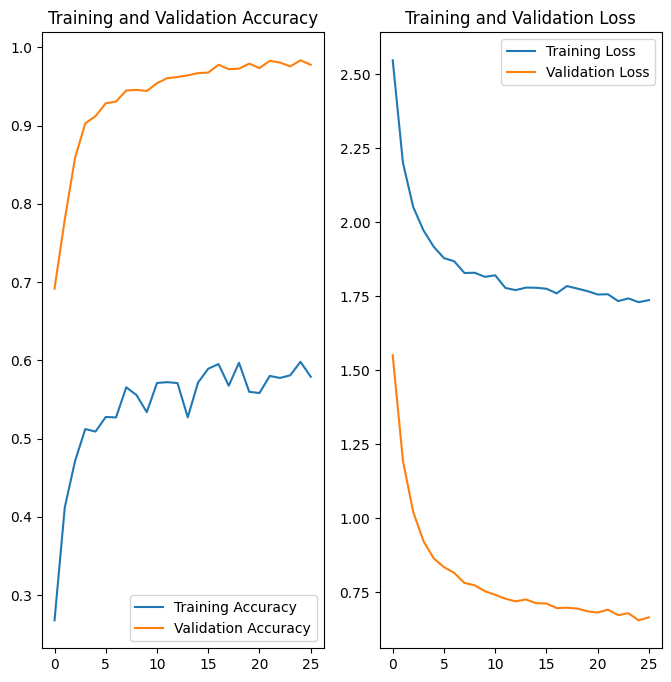

✅ Overall Accuracy: 0.9900
✅ Overall Precision: 0.9901
✅ Overall Recall: 0.9900
✅ Overall F1-Score: 0.9900
✅ Overall ROC AUC Score: 0.9998

Classification Report:
                precision    recall  f1-score   support

    Antracnose       0.97      0.98      0.97       199
Bacterial Spot       0.98      0.96      0.97       185
  Healthy Leaf       0.99      0.99      0.99       178
     Leaf Curl       1.00      1.00      1.00       217
      Mealybug       1.00      1.00      1.00       152
  Mite Disease       1.00      1.00      1.00       168
        Mosaic       0.99      1.00      0.99       136
     Ring Spot       1.00      0.99      1.00       167

      accuracy                           0.99      1402
     macro avg       0.99      0.99      0.99      1402
  weighted avg       0.99      0.99      0.99      1402

Confusion matrix, without normalization


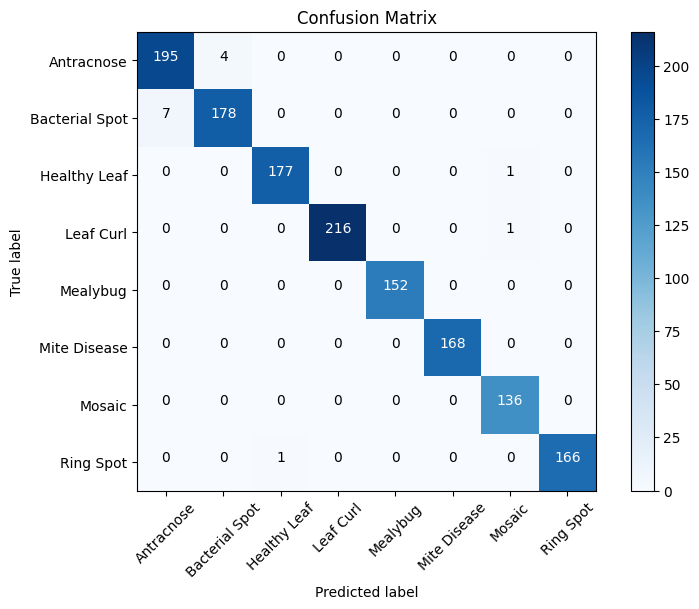

Normalized confusion matrix


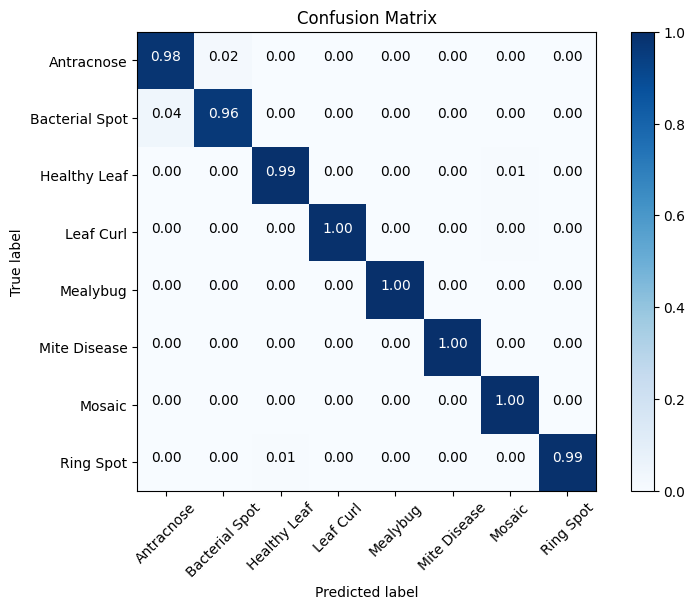

NameError: name 'extract_features_for_tsne' is not defined

In [22]:
# Install required libraries
!pip cache purge
!pip install torch torchvision timm pytorch-gradcam numpy matplotlib scikit-learn tqdm --no-cache-dir
# Verify installation
!pip show pytorch-gradcam

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import os
import time
from tqdm import tqdm
import timm
import pandas as pd
import seaborn as sns

# Import pytorch-gradcam with fallback
try:
    from pytorch_grad_cam import GradCAM, LayerCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
    print("pytorch_grad_cam modules imported successfully")
except ImportError:
    print("pytorch-gradcam not found. Attempting to install from GitHub...")
    !pip install git+https://github.com/jacobgil/pytorch-grad-cam.git --no-cache-dir
    from pytorch_grad_cam import GradCAM, LayerCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
    print("pytorch_grad_cam modules imported successfully from GitHub")

%matplotlib inline

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Constants
IMAGE_SIZE = 224
BATCH_SIZE = 16
CHANNELS = 3
EPOCHS = 50
NUM_CLASSES = 8
NUM_CLUSTERS = NUM_CLASSES
DATASET_PATH = '/kaggle/input/dataset/Augmented Dataset'
PATIENCE = 5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
DROP_PATH_RATE = 0.1
MIXUP_ALPHA = 0.2

# Enhanced data augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.3),  # Applied after ToTensor
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Mixup function
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# Load dataset
try:
    dataset = torchvision.datasets.ImageFolder(DATASET_PATH, transform=data_transforms['train'])
    class_names = dataset.classes
    print(f"Classes found: {class_names}")
    print(f"Dataset size: {len(dataset)}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    raise

# Dataset splitting
def dataset_split(dataset, train_split=0.70, val_split=0.15, test_split=0.15):
    dataset_size = len(dataset)
    indices = list(range(dataset_size))
    np.random.seed(12)
    np.random.shuffle(indices)
    
    train_size = int(train_split * dataset_size)
    val_size = int(val_split * dataset_size)
    
    train_indices = indices[:train_size]
    val_indices = indices[train_size:train_size + val_size]
    test_indices = indices[train_size + val_size:]
    
    train_sampler = SubsetRandomSampler(train_indices)
    val_sampler = SubsetRandomSampler(val_indices)
    test_sampler = SubsetRandomSampler(test_indices)
    
    train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0, pin_memory=True)
    val_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=val_sampler, num_workers=0, pin_memory=True)
    test_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=test_sampler, num_workers=0, pin_memory=True)
    
    print(f"Train size: {len(train_indices)}, Val size: {len(val_indices)}, Test size: {len(test_indices)}")
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = dataset_split(dataset)

# Cross-Attention Module
class CrossAttention(nn.Module):
    def __init__(self, dim, num_heads=8):
        super(CrossAttention, self).__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x1, x2):
        B, C = x1.size()
        qkv1 = self.qkv(x1).reshape(B, self.num_heads, 3, C // self.num_heads).permute(2, 0, 1, 3)
        qkv2 = self.qkv(x2).reshape(B, self.num_heads, 3, C // self.num_heads).permute(2, 0, 1, 3)
        
        q1, k1, v1 = qkv1[0], qkv1[1], qkv1[2]
        q2, k2, v2 = qkv2[0], qkv2[1], qkv2[2]
        
        attn1 = (q1 @ k2.transpose(-2, -1)) * self.scale
        attn1 = attn1.softmax(dim=-1)
        out1 = (attn1 @ v2).transpose(1, 2).reshape(B, C)
        
        attn2 = (q2 @ k1.transpose(-2, -1)) * self.scale
        attn2 = attn2.softmax(dim=-1)
        out2 = (attn2 @ v1).transpose(1, 2).reshape(B, C)
        
        out = self.proj(out1 + out2)
        out = self.dropout(out)
        return out

# Feature Extractor for K-means
class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super(FeatureExtractor, self).__init__()
        self.model = model
        self.model.head = nn.Identity()  # Remove classification head
    
    def forward(self, x):
        feats = self.model(x)
        if feats.dim() > 2:
            feats = torch.mean(feats, dim=(2, 3))  # Global average pooling
        return feats

# Extract features for K-means
def extract_features(model, loader):
    model.eval()
    features = []
    labels = []
    images = []
    
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Extracting features"):
            imgs = imgs.to(device)
            feats = model(imgs)
            features.append(feats.cpu().numpy())
            labels.append(lbls.numpy())
            images.append(imgs.cpu())
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    images = torch.cat(images, dim=0)
    print(f"Extracted features shape: {features.shape}")
    return features, labels, images

# Apply K-means clustering
def apply_kmeans(features, num_clusters):
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    print(f"Scaled features shape: {features_scaled.shape}")
    
    n_components = min(50, features.shape[1])
    pca = PCA(n_components=n_components)
    features_reduced = pca.fit_transform(features_scaled)
    print(f"Reduced features shape: {features_reduced.shape}")
    
    kmeans = KMeans(n_clusters=num_clusters, random_state=12, n_init=10)
    clusters = kmeans.fit_predict(features_reduced)
    return clusters, kmeans, pca

# Visualize clusters
def visualize_clusters(images, clusters, labels, class_names, num_clusters, num_images_per_cluster=3):
    plt.figure(figsize=(15, 10))
    for cluster_idx in range(num_clusters):
        idxs = np.where(clusters == cluster_idx)[0]
        if len(idxs) == 0:
            print(f"Warning: Cluster {cluster_idx} is empty")
            continue
        cluster_images = images[idxs]
        cluster_labels = labels[idxs]
        
        for i in range(min(num_images_per_cluster, len(cluster_images))):
            plt.subplot(num_clusters, num_images_per_cluster, cluster_idx * num_images_per_cluster + i + 1)
            img = cluster_images[i].numpy().transpose((1, 2, 0))
            img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img = np.clip(img, 0, 1)
            plt.imshow(img)
            plt.title(f"Cluster {cluster_idx}\nLabel: {class_names[cluster_labels[i]]}")
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Model definitions
def get_swin_tiny_transformer(num_classes, device):
    model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0, drop_path_rate=DROP_PATH_RATE)
    return model.to(device)

def get_mobilenetv3_small(num_classes, device):
    model = timm.create_model('mobilenetv3_small_100', pretrained=True, num_classes=0)
    return model.to(device)

# Ensemble model with Cross-Attention Fusion
class EnsembleModel(nn.Module):
    def __init__(self, swin_model, mobilenet_model, num_classes, feature_dim=768):  # Use 768 for Swin Tiny
        super(EnsembleModel, self).__init__()
        self.swin = swin_model
        self.mobilenet = mobilenet_model
        self.mobilenet_adaptor = nn.Linear(1024, 768)  # Adapt MobileNetV3 features to Swin Tiny dimension
        self.cross_attention = CrossAttention(feature_dim)
        self.dropout = nn.Dropout(0.6)
        self.fc = nn.Linear(feature_dim, num_classes)
    
    def forward(self, x):
        swin_features = self.swin(x)  # Shape: (batch_size, 768)
        mobilenet_features = self.mobilenet(x)  # Shape: (batch_size, 1024)
        mobilenet_features = self.mobilenet_adaptor(mobilenet_features)  # Adapt to 768
        fused = self.cross_attention(swin_features, mobilenet_features)
        fused = self.dropout(fused)
        output = self.fc(fused)
        return output

# Initialize models
swin_model = get_swin_tiny_transformer(NUM_CLASSES, device)
mobilenet_model = get_mobilenetv3_small(NUM_CLASSES, device)
model = EnsembleModel(swin_model, mobilenet_model, NUM_CLASSES, feature_dim=768).to(device)

# Freeze base layers
for param in swin_model.parameters():
    param.requires_grad = False
for param in mobilenet_model.parameters():
    param.requires_grad = False

# Unfreeze last layers
swin_stages = getattr(swin_model, 'layers', [])
if swin_stages and len(swin_stages) > 0:
    for param in swin_stages[-1].parameters():
        param.requires_grad = True
else:
    print("Warning: No 'layers' found in Swin Transformer. Unfreezing norm.")
    for param in swin_model.norm.parameters():
        param.requires_grad = True

mobilenet_blocks = getattr(mobilenet_model, 'blocks', [])
if mobilenet_blocks and len(mobilenet_blocks) > 0:
    for param in mobilenet_blocks[-1].parameters():
        param.requires_grad = True
else:
    print("Warning: No 'blocks' found in MobileNetV3. Unfreezing conv_head.")
    for param in mobilenet_model.conv_head.parameters():
        param.requires_grad = True

# Unfreeze ensemble layers
for param in model.fc.parameters():
    param.requires_grad = True
for param in model.cross_attention.parameters():
    param.requires_grad = True
for param in model.mobilenet_adaptor.parameters():
    param.requires_grad = True

# Loss and optimizer with class weights and label smoothing
from collections import Counter
class_counts = Counter(dataset.targets)
total_samples = len(dataset)
class_weights = torch.tensor([total_samples / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
pseudo_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW([
    {'params': swin_model.parameters(), 'lr': 1e-6, 'weight_decay': WEIGHT_DECAY},
    {'params': mobilenet_model.parameters(), 'lr': 1e-6, 'weight_decay': WEIGHT_DECAY},
    {'params': model.fc.parameters(), 'lr': 1e-5, 'weight_decay': WEIGHT_DECAY},
    {'params': model.cross_attention.parameters(), 'lr': 1e-5, 'weight_decay': WEIGHT_DECAY},
    {'params': model.mobilenet_adaptor.parameters(), 'lr': 1e-5, 'weight_decay': WEIGHT_DECAY}
])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# K-means clustering for pseudo-supervision
feature_extractor = FeatureExtractor(get_swin_tiny_transformer(NUM_CLASSES, device)).to(device)
features, labels, images = extract_features(feature_extractor, train_loader)
clusters, kmeans, pca = apply_kmeans(features, NUM_CLUSTERS)
visualize_clusters(images, clusters, labels, class_names, NUM_CLUSTERS)

# Pseudo-labeling
pseudo_labels = torch.tensor(clusters, dtype=torch.long).to(device)

# Training loop with pseudo-supervision and Mixup
def train_model(model, train_loader, val_loader, criterion, pseudo_criterion, optimizer, num_epochs, patience=PATIENCE):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(num_epochs):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        pseudo_correct = 0
        
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', unit='batch')
        for batch_idx, (images, labels) in enumerate(train_pbar):
            images, labels = images.to(device), labels.to(device)
            
            # Apply Mixup
            images, labels_a, labels_b, lam = mixup_data(images, labels, MIXUP_ALPHA)
            
            optimizer.zero_grad()
            outputs = model(images)
            
            # Supervised loss with Mixup
            loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
            
            # Pseudo-supervision loss
            batch_start = batch_idx * BATCH_SIZE
            batch_end = min(batch_start + BATCH_SIZE, len(pseudo_labels))
            batch_pseudo_labels = pseudo_labels[batch_start:batch_end]
            if batch_pseudo_labels.size(0) == outputs.size(0):
                pseudo_loss = pseudo_criterion(outputs, batch_pseudo_labels)
                loss = loss + 0.3 * pseudo_loss
            else:
                print(f"Warning: Pseudo-label size mismatch at batch {batch_idx}")
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels_a).sum().item()
            pseudo_correct += (predicted == batch_pseudo_labels).sum().item() if batch_pseudo_labels.size(0) == outputs.size(0) else 0
            
            train_pbar.set_postfix({
                'loss': running_loss / total,
                'accuracy': correct / total,
                'pseudo_acc': pseudo_correct / total if total > 0 else 0
            })
        
        train_loss = running_loss / total
        train_acc = correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss = val_loss / total
        val_acc = correct / total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        scheduler.step(val_loss)
        
        epoch_time = time.time() - start_time
        steps_per_epoch = len(train_loader)
        time_per_step = epoch_time / steps_per_epoch
        
        print(f"{steps_per_epoch}/{steps_per_epoch} ━━━━━━━━━━━━━━━━━━━━ {int(epoch_time)}s {int(time_per_step)}s/step - accuracy: {train_acc:.4f} - loss: {train_loss:.4f} - val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            torch.save(best_model_state, '/kaggle/working/best_checkpoint.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                model.load_state_dict(best_model_state)
                break
        
        torch.save(model.state_dict(), '/kaggle/working/checkpoint.pt')
    
    return history

# Train the model
history = train_model(model, train_loader, val_loader, criterion, pseudo_criterion, optimizer, EPOCHS)

# Plot training history
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Load the best model for evaluation
model.load_state_dict(torch.load('/kaggle/working/best_checkpoint.pt'))

# Evaluation
def evaluate_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    y_probs = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
    roc_auc = roc_auc_score(y_true_bin, y_probs, average='weighted', multi_class='ovr')
    
    print(f"✅ Overall Accuracy: {accuracy:.4f}")
    print(f"✅ Overall Precision: {precision:.4f}")
    print(f"✅ Overall Recall: {recall:.4f}")
    print(f"✅ Overall F1-Score: {f1:.4f}")
    print(f"✅ Overall ROC AUC Score: {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix'):
        if normalize:
            cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
            print("Normalized confusion matrix")
        else:
            print('Confusion matrix, without normalization')
        
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(title)
        plt.colorbar()
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes, rotation=45)
        plt.yticks(tick_marks, classes)
        
        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2.
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            plt.text(j, i, format(cm[i, j], fmt),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        
        plt.tight_layout()
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.show()
    
    plot_confusion_matrix(cm, class_names)
    plot_confusion_matrix(cm, class_names, normalize=True)
    
    return y_true, y_pred, y_probs

y_true, y_pred, y_probs = evaluate_model(model, test_loader)

# Pearson Correlation Analysis
features, labels = extract_features_for_tsne(feature_extractor, test_loader)
correlation_matrix = np.corrcoef(features, rowvar=False)
correlation_df = pd.DataFrame(correlation_matrix)
print("Pearson Correlation Matrix:")
print(correlation_df)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_df, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Pearson Correlation Matrix of Features")
plt.show()

upper_tri = correlation_df.where(np.triu(np.ones(correlation_df.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]
features_reduced = np.delete(features, [correlation_df.columns.get_loc(col) for col in to_drop], axis=1)
print(f"Removed {len(to_drop)} highly correlated features. New shape: {features_reduced.shape}")

# t-SNE Visualization
def extract_features_for_tsne(model, loader):
    model.eval()
    features = []
    labels = []
    
    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(device)
            feats = model(images)
            if feats.dim() > 2:
                feats = torch.mean(feats, dim=(2, 3))
            features.append(feats.cpu().numpy())
            labels.append(lbls.numpy())
    
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    return features_scaled, labels

def apply_tsne(features, n_components=2, perplexity=40, n_iter=2000):
    tsne = TSNE(n_components=n_components, perplexity=perplexity, n_iter=n_iter, random_state=42, learning_rate='auto')
    features_2d = tsne.fit_transform(features)
    return features_2d

def visualize_tsne(features_2d, labels, class_names):
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, cmap='tab10', s=50, alpha=0.6)
    plt.colorbar(scatter, ticks=range(len(class_names)), label='Classes')
    plt.clim(-0.5, len(class_names) - 0.5)
    plt.title('t-SNE Visualization of Model Features', fontsize=14)
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.xticks([])
    plt.yticks([])
    plt.legend(handles=scatter.legend_elements()[0], labels=class_names, loc='best', title='Classes', fontsize=10)
    plt.tight_layout()
    plt.show()

feature_extractor = FeatureExtractor(model).to(device)
features, labels = extract_features_for_tsne(feature_extractor, test_loader)
features_2d = apply_tsne(features)
visualize_tsne(features_2d, labels, class_names)

# Model size and inference speed
def measure_model_size_and_speed(model):
    torch.save(model.state_dict(), '/kaggle/working/ensemble_model.pt')
    model_size_mb = os.path.getsize('/kaggle/working/ensemble_model.pt') / (1024 * 1024)
    print(f"Model Size: {model_size_mb:.2f} MB")
    
    model.eval()
    dummy_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    times = []
    for _ in range(10):
        start_time = time.time()
        with torch.no_grad():
            _ = model(dummy_input)
        times.append((time.time() - start_time) * 1000)
    
    avg_inference_time = sum(times) / len(times)
    print(f"Average Inference Time: {avg_inference_time:.2f} ms per image")

measure_model_size_and_speed(model)